In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
def matrix_mult(A, B):
    #A(y,x) * B(x,z) = C(y,z)
    start = time.time()
    x = np.shape(A)[1]
    y = np.shape(A)[0]
    z = np.shape(B)[1]
    
    C = np.zeros((y, z))
    
    for i in range(y):
        for j in range(z):
            for k in range(x):
                C[i, j] += A[i,k] * B[k,j]
    
    end = time.time()
    elapsed_time = end - start
    
    return elapsed_time

In [3]:
def rand_matrix(size):
    x = size
    y = size
    A = np.zeros((x, y))
    B = np.zeros((x, y))
    
    for i in range(y):
        for j in range(x):
            A[i, j] = np.random.rand()
            B[i, j] = np.random.rand()
    
    return A, B

In [8]:
def compare_times(init_size, n):
    
    size = init_size*2**n
    A, B = rand_matrix(size)
    time_naive = matrix_mult(A, B)
    
    start = time.time()
    np.matmul(A,B)
    end = time.time()
    time_opt = end - start
    
    print(size,"x",size,"\n","Naive time:", time_naive, "\nOptimized time:", time_opt, "\n")
    
    return time_naive, time_opt

In [9]:
n = 8

time_naive = np.zeros(n)
time_opt = np.zeros(n)

for i in range(n):
    time_naive[i], time_opt[i] = compare_times(3, i)



3 x 3 
 Naive time: 9.417533874511719e-05 
Optimized time: 3.0279159545898438e-05 

6 x 6 
 Naive time: 0.0005939006805419922 
Optimized time: 3.457069396972656e-05 

12 x 12 
 Naive time: 0.003797292709350586 
Optimized time: 3.147125244140625e-05 

24 x 24 
 Naive time: 0.025296449661254883 
Optimized time: 5.888938903808594e-05 

48 x 48 
 Naive time: 0.1143486499786377 
Optimized time: 5.817413330078125e-05 

96 x 96 
 Naive time: 0.7430615425109863 
Optimized time: 0.0009145736694335938 

192 x 192 
 Naive time: 5.8754823207855225 
Optimized time: 0.0013337135314941406 

384 x 384 
 Naive time: 47.137643575668335 
Optimized time: 0.0019142627716064453 



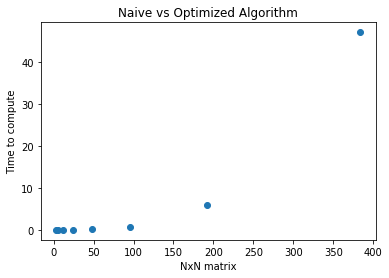

In [49]:
plt.figure()

exp = np.arange(n)
x = np.ones((n)) 
x = 3 * 2**exp

plt.scatter(x, time_naive)
plt.xlabel("NxN matrix")
plt.ylabel("Time to compute")
plt.title("Naive vs Optimized Algorithm")
plt.show()

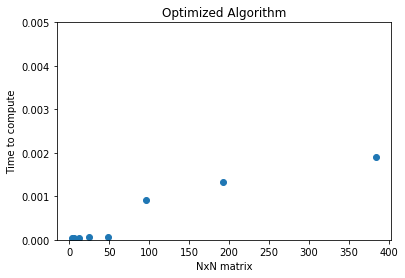

In [50]:
plt.figure()

plt.scatter(x, time_opt)
plt.ylim(0, 0.005)
plt.xlabel("NxN matrix")
plt.ylabel("Time to compute")
plt.title("Optimized Algorithm")
plt.show()

Because the naive algorithm has 3 nested loops, it should be O(N^3), and the data shows that doubling the input requires about 8 times the work each time. Based off the graph of the optimized algorithm, the big O seems to be logarithmic.